In [1]:
from cosipy import COSILike
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter
from threeML.minimizer.minimization import CannotComputeCovariance

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()

from scipy.integrate import quad

import matplotlib.ticker as mticker

from pathlib import Path

import os

%matplotlib inline

12:59:35 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=606086;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=597746;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=452400;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=550298;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=290216;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=974299;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

12:59:35 INFO      Starting 3ML!                                                                     ]8;id=941702;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=489563;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=816298;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=748378;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=556514;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=818499;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=610451;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=192348;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=303706;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=649053;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=735313;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=129807;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=943588;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=104112;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
data_path = Path("/Users/parshadkp/Software/COSI_Data/")

In [3]:
sc_orientation = SpacecraftFile.parse_from_file(data_path /"DC3_Files/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori") #DC3

In [4]:
dr = str(data_path / "DC3_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse_nside8.area.good_chunks.h5") # DC3

In [28]:
multiplier_4151 = 3
multiplier_1068 = 1

# Source Model Plots

## Cutoff Power Law (Thermal)

#### NGC 4151 (200 keV)

In [29]:
K_inj = 0.15*multiplier_4151 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

#### NGC 4151 (1000 keV)

In [30]:
K_inj = 0.15*multiplier_4151 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.75

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

#### NGC 1068 (200 keV)

In [31]:
K_inj = 3.1e-1*multiplier_1068 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.92

spectrum_inj_1068 = Cutoff_powerlaw()

spectrum_inj_1068.K.value = K_inj.value
spectrum_inj_1068.piv.value = piv_inj.value
spectrum_inj_1068.xc.value = xc_inj.value
spectrum_inj_1068.index.value = index_inj

spectrum_inj_1068.K.unit = K_inj.unit
spectrum_inj_1068.piv.unit = piv_inj.unit
spectrum_inj_1068.xc.unit = xc_inj.unit

# Power law tail (Non-thermal)

#### NGC 4151 (200 keV)

In [32]:
# K_inj = 0.1*spectrum_inj_ec200.evaluate_at(1000) / u.cm / u.cm / u.s / u.keV
# piv_inj = 1000. * u.keV

K_inj = 0.15*spectrum_inj_ec200.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

print(spectrum_inj_ec200.evaluate_at(200))
print(spectrum_inj_ec200_PL.evaluate_at(200))
print("="*40)
print("Linking ratio", spectrum_inj_ec200_PL.evaluate_at(200)/spectrum_inj_ec200.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_ec200.evaluate_at, 200.0, 5000.0)
flux_nth, _ = quad(spectrum_inj_ec200_PL.evaluate_at, 200.0, 5000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

1.5563796348962474e-05
2.334569452344372e-06
Linking ratio 0.15000000000000005
Non-thermal flux:  0.00016673464448250684
Total flux:  0.00153887242321468
Thermal - Non-thermal Flux Ratio:  8.22947014395759
Non-thermal percentage:  0.10834858170646844


#### NGC 4151 (1000 keV)

In [33]:
# K_inj = (spectrum_inj_ec1000.evaluate_at(3000)) / u.cm / u.cm / u.s / u.keV
K_inj = spectrum_inj_ec200_PL.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec1000_PL = Powerlaw()

spectrum_inj_ec1000_PL.K.value = K_inj.value
spectrum_inj_ec1000_PL.piv.value = piv_inj.value
spectrum_inj_ec1000_PL.index.value = index_inj

spectrum_inj_ec1000_PL.K.unit = K_inj.unit
spectrum_inj_ec1000_PL.piv.unit = piv_inj.unit

spectrum_inj_ec1000_total = spectrum_inj_ec1000 + spectrum_inj_ec1000_PL

print(spectrum_inj_ec1000.evaluate_at(200))
print(spectrum_inj_ec1000_PL.evaluate_at(200))
print("="*40)
print("Linking ratio", spectrum_inj_ec1000_PL.evaluate_at(200)/spectrum_inj_ec1000.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_ec1000.evaluate_at, 200.0, 5000.0)
flux_nth, _ = quad(spectrum_inj_ec1000_PL.evaluate_at, 200.0, 5000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

3.463786577733764e-05
2.334569452344372e-06
Linking ratio 0.06739934461758323
Non-thermal flux:  0.00016673464448250684
Total flux:  0.005853331673582991
Thermal - Non-thermal Flux Ratio:  34.105671600224035
Non-thermal percentage:  0.028485425699521963


#### NGC 1068 (200 keV)

In [34]:
# K_inj = 0.1*((3.1e-1)*100) / u.cm / u.cm / u.s / u.keV
K_inj = 0.15*spectrum_inj_1068.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_1068_PL = Powerlaw()

spectrum_inj_1068_PL.K.value = K_inj.value
spectrum_inj_1068_PL.piv.value = piv_inj.value
spectrum_inj_1068_PL.index.value = index_inj

spectrum_inj_1068_PL.K.unit = K_inj.unit
spectrum_inj_1068_PL.piv.unit = piv_inj.unit

spectrum_inj_1068_total = spectrum_inj_1068 + spectrum_inj_1068_PL

print(spectrum_inj_1068.evaluate_at(200))
print(spectrum_inj_1068_PL.evaluate_at(200))
print("="*40)
print("Linking ratio", spectrum_inj_1068_PL.evaluate_at(200)/spectrum_inj_1068.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_1068.evaluate_at, 200.0, 5000.0)
flux_nth, _ = quad(spectrum_inj_1068_PL.evaluate_at, 200.0, 5000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

4.356017544341019e-06
6.534026316511528e-07
Linking ratio 0.15
Non-thermal flux:  4.6665930363685256e-05
Total flux:  0.00040815881601294606
Thermal - Non-thermal Flux Ratio:  7.7463983431169146
Non-thermal percentage:  0.11433277570612391


### NGC 4151 Faint

In [35]:
K_inj = 0.035*multiplier_4151 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.81

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

spectrum_inj_ec1000_total = spectrum_inj_ec1000 + spectrum_inj_ec1000_PL

print(spectrum_inj_ec1000.evaluate_at(200))
print(spectrum_inj_ec1000_PL.evaluate_at(200))
print("="*40)
print("Linking ratio", spectrum_inj_ec1000_PL.evaluate_at(200)/spectrum_inj_ec1000.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_ec1000.evaluate_at, 200.0, 5000.0)
flux_nth, _ = quad(spectrum_inj_ec1000_PL.evaluate_at, 200.0, 5000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

5.881202193490103e-06
2.334569452344372e-06
Linking ratio 0.39695446195141953
Non-thermal flux:  0.00016673464448250684
Total flux:  0.0010949649609060922
Thermal - Non-thermal Flux Ratio:  5.5671112581583
Non-thermal percentage:  0.15227395435971997


### NGC 4151 Bright

In [36]:
K_inj = 0.15*multiplier_4151 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 264. * u.keV
index_inj = -1.71

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

print(spectrum_inj_ec200.evaluate_at(200))
print(spectrum_inj_ec200_PL.evaluate_at(200))
print("="*40)
print("Linking ratio", spectrum_inj_ec200_PL.evaluate_at(200)/spectrum_inj_ec200.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_ec200.evaluate_at, 200.0, 5000.0)
flux_nth, _ = quad(spectrum_inj_ec200_PL.evaluate_at, 200.0, 5000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

2.4515471483642874e-05
2.334569452344372e-06
Linking ratio 0.09522841336753549
Non-thermal flux:  0.00016673464448250684
Total flux:  0.0026875267719731607
Thermal - Non-thermal Flux Ratio:  15.11858639405397
Non-thermal percentage:  0.0620401799235256


#### NGC 4151 (200 keV) Non-thermal cutoff

In [79]:
# K_inj = 0.1*spectrum_inj_ec200.evaluate_at(1000) / u.cm / u.cm / u.s / u.keV
# piv_inj = 1000. * u.keV

K_inj = 0.10*spectrum_inj_ec200.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -1.7
cutoff_inj = 1200. * u.keV

spectrum_inj_ec200_PL = Cutoff_powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj
spectrum_inj_ec200_PL.xc.value = cutoff_inj.value

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit
spectrum_inj_ec200_PL.xc.unit = cutoff_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

print(spectrum_inj_ec200.evaluate_at(200))
print(spectrum_inj_ec200_PL.evaluate_at(200))
print("="*40)
print(spectrum_inj_ec200_PL.evaluate_at(200)/spectrum_inj_ec200.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_ec200.evaluate_at, 200.0, 5000.0)
flux_nth, _ = quad(spectrum_inj_ec200_PL.evaluate_at, 200.0, 5000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

5.187932116320825e-06
4.3914897264386647e-07
0.0846481724890614
Non-thermal flux:  7.825719874323576e-05
Total flux:  0.0005356364583206269
Thermal - Non-thermal Flux Ratio:  5.844564678044079
Non-thermal percentage:  0.14610132960066682


#### NGC 4151 (1000 keV) Non-thermal cutoff

In [ ]:
# K_inj = 0.1*spectrum_inj_ec200.evaluate_at(1000) / u.cm / u.cm / u.s / u.keV
# piv_inj = 1000. * u.keV

K_inj = 0.1*spectrum_inj_ec1000.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -1.7
cutoff_inj = 1500. * u.keV

spectrum_inj_ec1000_PL = Cutoff_powerlaw()

spectrum_inj_ec1000_PL.K.value = K_inj.value
spectrum_inj_ec1000_PL.piv.value = piv_inj.value
spectrum_inj_ec1000_PL.index.value = index_inj
spectrum_inj_ec1000_PL.xc.value = cutoff_inj.value

spectrum_inj_ec1000_PL.K.unit = K_inj.unit
spectrum_inj_ec1000_PL.piv.unit = piv_inj.unit
spectrum_inj_ec1000_PL.xc.unit = cutoff_inj.unit

spectrum_inj_ec1000_total = spectrum_inj_ec1000 + spectrum_inj_ec1000_PL

print(spectrum_inj_ec1000.evaluate_at(200))
print(spectrum_inj_ec1000_PL.evaluate_at(200))
print("="*40)
print(spectrum_inj_ec1000_PL.evaluate_at(200)/spectrum_inj_ec1000.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_ec1000.evaluate_at, 200.0, 5000.0)
flux_nth, _ = quad(spectrum_inj_ec1000_PL.evaluate_at, 200.0, 5000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

1.1545955259112548e-05
4.662778797786435e-07
0.040384521619433573
Non-thermal flux:  8.309162261664591e-05
Total flux:  0.0019786239656501402
Thermal - Non-thermal Flux Ratio:  22.812556589233807
Non-thermal percentage:  0.04199465085794789


In [80]:
# energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)
# energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_inj_ec200 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)
flux_inj_1068 = np.zeros_like(energy)
flux_inj_ec200_PL = np.zeros_like(energy)
flux_inj_ec1000_PL = np.zeros_like(energy)
flux_inj_1068_PL = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)
    flux_inj_ec200[i] = spectrum_inj_ec200.evaluate_at(e)
    flux_inj_1068[i] = spectrum_inj_1068.evaluate_at(e)
    flux_inj_ec200_PL[i] = spectrum_inj_ec200_PL.evaluate_at(e)
    flux_inj_ec1000_PL[i] = spectrum_inj_ec1000_PL.evaluate_at(e)
    flux_inj_1068_PL[i] = spectrum_inj_1068_PL.evaluate_at(e)

Plot the fitted and injected spectra

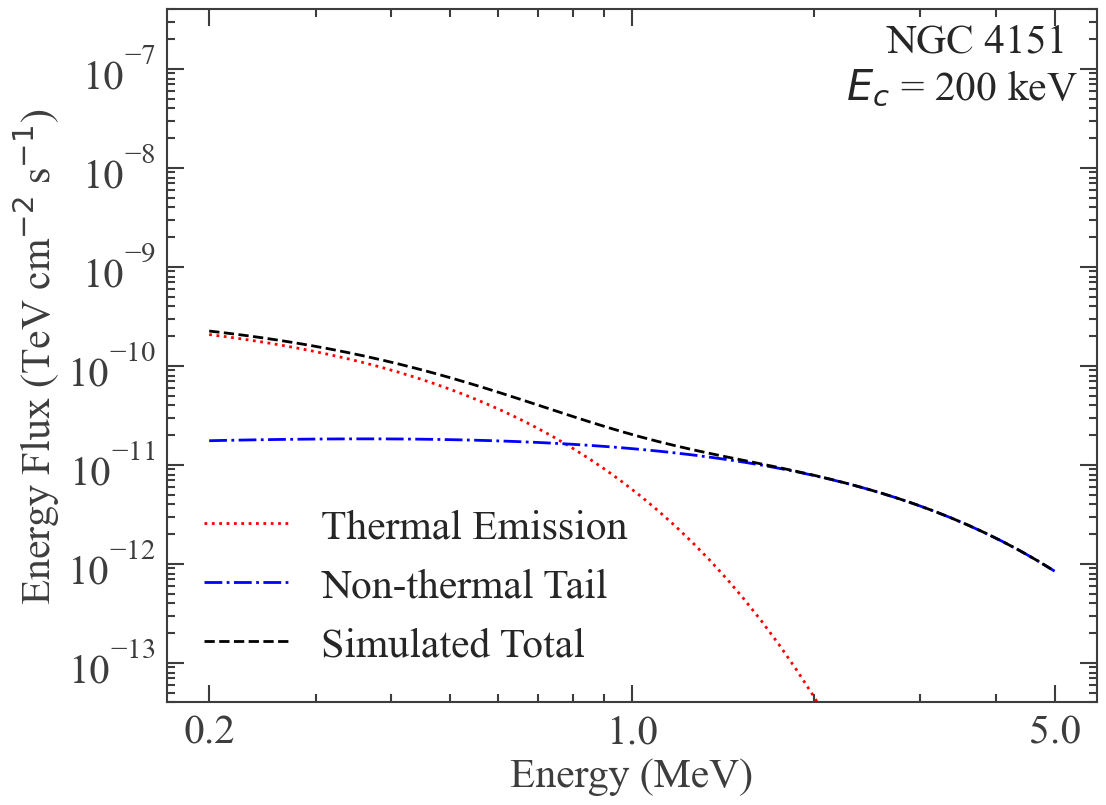

In [81]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9))

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

# # 200 keV cutoff
# text = 'NGC 4151 \n $E_{c}$ = 200 keV'
# total_flux_ec200 = flux_inj_ec200 + flux_inj_ec200_PL
# ax.plot(energy, energy*energy*flux_inj_ec200, color = 'red', ls = ":", label = "Thermal Emission")
# ax.plot(energy, energy*energy*flux_inj_ec200_PL, color = 'blue', ls = "-.", label = "Non-thermal Tail")
# ax.plot(energy, energy*energy*total_flux_ec200, color = 'black', ls = "--", label = "Simulated Total")
# ax.set_ylim(4e-14, 4e-7)
# ax.text(
#     0.98, 0.98,
#     text,
#     transform=ax.transAxes,
#     ha='right', va='top',
#     fontsize=FONT_SIZE,
#     fontweight='550'
# )
# save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_TH_NTH_EC200.pdf"

# # # 1000 keV cutoff
# text = 'NGC 4151 \n $E_{c}$ = 1000 keV'
# total_flux_ec1000 = flux_inj_ec1000 + flux_inj_ec1000_PL
# ax.plot(energy, energy*energy*flux_inj_ec1000, color = 'red', ls = ":", label = "Thermal Emission")
# ax.plot(energy, energy*energy*flux_inj_ec1000_PL, color = 'blue', ls = "-.", label = "Non-thermal Tail")
# ax.plot(energy, energy*energy*total_flux_ec1000, color = 'black', ls = "--", label = "Simulated Total")
# ax.set_ylim(1e-6, 10)
# ax.text(
#     0.98, 0.98,
#     text,
#     transform=ax.transAxes,
#     ha='right', va='top',
#     fontsize=FONT_SIZE,
#     fontweight='550'
# )
# save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_TH_NTH_EC1000.pdf"

# # # NGC 1068
# text = 'NGC 1068 \n $E_c$ = 200 keV'
# total_flux_1068 = flux_inj_1068 + flux_inj_1068_PL
# ax.plot(energy, energy*energy*flux_inj_1068, color = 'red', ls = ":", label = "Thermal Emission")
# ax.plot(energy, energy*energy*flux_inj_1068_PL, color = 'blue', ls = "-.", label = "Non-thermal Tail")
# ax.plot(energy, energy*energy*total_flux_1068, color = 'black', ls = "--", label = "Simulated Total")
# ax.set_ylim(1e-6, 10)
# ax.text(
#     0.98, 0.98,
#     text,
#     transform=ax.transAxes,
#     ha='right', va='top',
#     fontsize=FONT_SIZE,
#     fontweight='550'
# )
# save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC1068_TH_NTH_EC200.pdf"

# 200 keV cutoff in TeV
text = 'NGC 4151 \n $E_{c}$ = 200 keV'
total_flux_ec200 = flux_inj_ec200 + flux_inj_ec200_PL
ax.plot(energy, energy*energy*flux_inj_ec200*(1e-9), color = 'red', ls = ":", label = "Thermal Emission")
ax.plot(energy, energy*energy*flux_inj_ec200_PL*(1e-9), color = 'blue', ls = "-.", label = "Non-thermal Tail")
ax.plot(energy, energy*energy*total_flux_ec200*(1e-9), color = 'black', ls = "--", label = "Simulated Total")
ax.set_ylim(4e-14, 4e-7)
ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (TeV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# plt.savefig(save_path)

# Spectral Fitting

In [43]:
bat_rsp_ec200 = "/Users/parshadkp/Software/COSI_Data/AGN_Data/XRay/swiftbat_survey_full.rsp"
bat_pha_ec200 = "/Users/parshadkp/Software/COSI_Data/AGN_Data/XRay/SWIFT_J1210.5+3924_resp.pha"

bat_rsp_ec1000 = data_path/"AGN_Data/XRay/Simulations/BAT_157m_swiftbat_survey_full_157m.rsp"
bat_pha_ec1000 = data_path/"AGN_Data/XRay/Simulations/simulate_bat_ec_1000_gamma_1dot75.pha"

bat_ec200 = OGIPLike("BAT", observation=bat_pha_ec200, response=bat_rsp_ec200)
bat_ec1000 = OGIPLike("BAT", observation=bat_pha_ec1000, response=bat_rsp_ec1000)

bat_ec200.set_active_measurements("40-200")
bat_ec1000.set_active_measurements("40-200")

# bat_ec200.view_count_spectrum()
# bat_ec1000.view_count_spectrum()

17:18:23 INFO      Auto-probed noise models:                                                    ]8;id=781710;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=194211;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: gaussian                                                      ]8;id=921088;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=104804;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: None                                                           ]8;id=630145;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=131770;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Auto-probed noise models:                                                    ]8;id=667021;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=682548;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: gaussian                                                      ]8;id=218135;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=459688;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: None                                                           ]8;id=963000;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=995091;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=605145;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=667043;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=881376;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=228013;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

In [37]:
# NGC4151_ec200 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl_pl.hdf5")*multiplier_4151
# bkg = Histogram.open(data_path /  "DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_TimeCut.hdf5")*multiplier_4151
# NGC4151_ec200_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC4_COSI_cpl_pl_TimeCutBkg.hdf5")*multiplier_4151

# NGC4151_ec200 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl.hdf5")*multiplier_4151
# bkg = Histogram.open(data_path /  "DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck.hdf5")*multiplier_4151
# NGC4151_ec200_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC4_COSI_cpl_TimeCutBkg.hdf5")*multiplier_4151

NGC4151_ec200 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec264_DC3_COSI_cpl_pl_bright.hdf5")*multiplier_4151
bkg = Histogram.open(data_path /  "DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_TimeCut.hdf5")*multiplier_4151
NGC4151_ec200_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec264_DC4_COSI_cpl_pl_bright_TimeCutBkg.hdf5")*multiplier_4151

In [38]:
# NGC4151_ec1000 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC3_COSI_cpl_pl.hdf5")*multiplier_4151
# NGC4151_ec1000_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC4_COSI_cpl_pl_TimeCutBkg.hdf5")*multiplier_4151

# NGC4151_ec1000 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC3_COSI_cpl.hdf5")*multiplier_4151
# NGC4151_ec1000_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC4_COSI_cpl_TimeCutBkg.hdf5")*multiplier_4151

NGC4151_ec1000 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC3_COSI_cpl_pl_faint.hdf5")*multiplier_4151
NGC4151_ec1000_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC4_COSI_cpl_pl_faint_TimeCutBkg.hdf5")*multiplier_4151

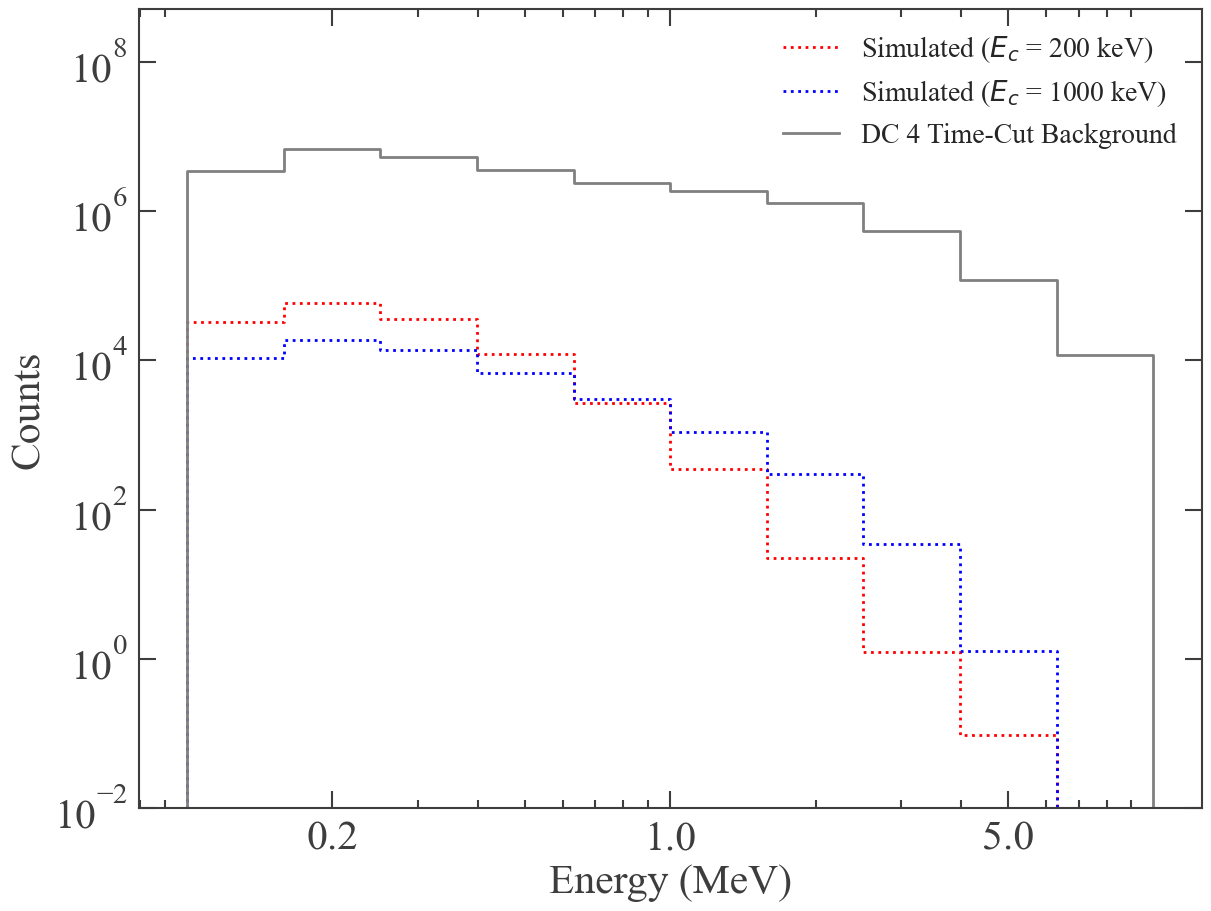

In [50]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

NGC4151_ec200.project("Em").draw(ax, label="Simulated ($E_c$ = 200 keV)", color="red", linestyle="dotted")
NGC4151_ec1000.project("Em").draw(ax, label="Simulated ($E_c$ = 1000 keV)", color="blue", linestyle="dotted")
bkg.project("Em").draw(ax, label="DC 4 Time-Cut Background", color="grey")
# NGC4151_ec200_bkg.project("Em").draw(ax, label="NGC 4151 Model + Background", linestyle='dashdot', color="blue")
# NGC4151_ec1000_bkg.project("Em").draw(ax, label="NGC4151 TH + NTH + Time-Cut Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e-2, 5e8)

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=20, loc='upper right', frameon=False)

# save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_FullModel_Counts_200_1000_3Months.pdf"
# plt.savefig(save_path)

Define the path to the detector response

## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [39]:
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

cosi_ec1000 = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec1000_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

### Powerlaw with energy cutoff fit

In [40]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 100. * u.keV
# index = -1.75
index = -1.71

spectrum_cpl = Cutoff_powerlaw()

spectrum_cpl.K.value = K.value
spectrum_cpl.piv.value = piv.value
spectrum_cpl.xc.value = xc.value
spectrum_cpl.index.value = index
spectrum_cpl.index.fix = True

# Harsher Parameters
spectrum_cpl.K.min_value = 1e-8
spectrum_cpl.K.max_value = 1e-2
spectrum_cpl.xc.min_value = 100 # keep these relatively the same
spectrum_cpl.xc.max_value = 10000 # change to 1000
# spectrum_cpl.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
# spectrum_cpl.index.max_value = 1

# spectrum_cpl.K.delta = 0.05
# spectrum_cpl.xc.delta = 10
# spectrum_cpl.index.delta = 0.15

spectrum_cpl.K.unit = K.unit
spectrum_cpl.piv.unit = piv.unit
spectrum_cpl.xc.unit = xc.unit

source1 = PointSource("source1",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

In [41]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 1000. * u.keV
# index = -1.75
index = -1.81

spectrum_cpl_ec1000 = Cutoff_powerlaw()

spectrum_cpl_ec1000.K.value = K.value
spectrum_cpl_ec1000.piv.value = piv.value
spectrum_cpl_ec1000.xc.value = xc.value
spectrum_cpl_ec1000.index.value = index
spectrum_cpl_ec1000.index.fix = True

# Harsher Parameters
spectrum_cpl_ec1000.K.min_value = 1e-8
spectrum_cpl_ec1000.K.max_value = 1e-2
spectrum_cpl_ec1000.xc.min_value = 100 # keep these relatively the same
spectrum_cpl_ec1000.xc.max_value = 10000 # change to 1000
# spectrum_cpl_ec1000.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
# spectrum_cpl_ec1000.index.max_value = 1

# spectrum_cpl_ec1000.K.delta = 0.05
# spectrum_cpl_ec1000.xc.delta = 10
# spectrum_cpl_ec1000.index.delta = 0.15

spectrum_cpl_ec1000.K.unit = K.unit
spectrum_cpl_ec1000.piv.unit = piv.unit
spectrum_cpl_ec1000.xc.unit = xc.unit

source2 = PointSource("source2",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl_ec1000)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

## Just Thermal Fit

In [155]:
# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
model = Model(source1)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)
model_ec1000 = Model(source2)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

cosi.set_model(model)
cosi_ec1000.set_model(model_ec1000)

### Joint Fit

In [ ]:
# bat_ec200.use_effective_area_correction(0.2, 1.8)
# plugins = DataList(bat_ec200, cosi)

# bat_ec1000.use_effective_area_correction(0.2, 1.8)
# plugins_ec1000 = DataList(bat_ec1000, cosi_ec1000)

### Normal Fit

In [156]:
# ## Only COSI fit
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)
plugins_ec1000 = DataList(cosi_ec1000)

In [157]:
like = JointLikelihood(model, plugins, verbose = False)
like_ec1000 = JointLikelihood(model_ec1000, plugins_ec1000, verbose = False)

result = like.fit()
result_ec1000 = like_ec1000.fit()

22:45:01 INFO      set the minimizer to minuit                                             ]8;id=949552;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=533244;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=919832;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=711551;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(10.000000 +/- 0.000010) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.xc,(3.83 +/- 0.05) x 10^2,keV
background_cosi,1.00046 +/- 0.00009,


...

1.00,-0.86,-0.12
-0.86,1.00,-0.23
-0.12,-0.23,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1.312710e+09
total,-1.312710e+09


Values of statistical measures:

,statistical measures
AIC,-2.625420e+09
BIC,-2.625420e+09


In [104]:
def make_null_likelihood(data_hist):
    cosi_null = COSILike("cosi",                                                # COSI 3ML plugin
                     dr = dr,                                                    # detector response
                     data = data_hist.project('Em', 'Phi', 'PsiChi'),            # data (source+background)
                     bkg = bkg.project('Em', 'Phi', 'PsiChi'),                   # background model
                     sc_orientation = sc_orientation,                            # spacecraft orientation
                     nuisance_param = bkg_par,                                   # background parameter
                     earth_occ = True)                                           # Match the source fits

    spectrum_null = Powerlaw()
    spectrum_null.K.value = 1e-30
    spectrum_null.index.value = 1
    spectrum_null.K.fix = True
    spectrum_null.index.fix = True

    source_null = PointSource(
        "source_null",
        l=l,
        b=b,
        spectral_shape=spectrum_null,
    )

    model_null = Model(source_null)
    cosi_null.set_model(model_null)

    plugins_null = DataList(cosi_null)
    like_null = JointLikelihood(model_null, plugins_null, verbose=False)
    like_null.fit()

    return like_null

like_null_200 = make_null_likelihood(NGC4151_ec200_bkg)
like_null_1000 = make_null_likelihood(NGC4151_ec1000_bkg)

TS = 2 * (
    like_null_200.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

TS_ec1000 = 2 * (
    like_null_1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

print("L1", -like.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null_200.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS)
print("Significance [200 keV]: ", np.sqrt(TS))

print("L1", -like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null_1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS_ec1000)
print("Significance [1000 keV]: ", np.sqrt(TS_ec1000))

22:25:46 INFO      set the minimizer to minuit                                             ]8;id=876299;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=667258;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
background_cosi,1.00562 +/- 0.00012,


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-4.181655e+08
total,-4.181655e+08


Values of statistical measures:

,statistical measures
AIC,-8.363309e+08
BIC,-8.363309e+08


L1 419964774.6970587
L0 419962827.62455624
TS Value:  3894.1450048685074
Significance [200 keV]:  62.403084898653105
L1 418165684.3677979
L0 418165462.0919017
TS Value:  444.55179238319397
Significance [1000 keV]:  21.084396893987602


In [121]:
results = like.results
results_ec1000 = like_ec1000.results

# print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source1"].parameters.values()
              if par.free}
parameters_ec1000 = {par.name:results_ec1000.get_variates(par.path)
              for par in results_ec1000.optimized_model["source2"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source1"].spectrum.main.shape.evaluate_at, **parameters)
results_err_ec1000 = results_ec1000.propagate(results_ec1000.optimized_model["source2"].spectrum.main.shape.evaluate_at, **parameters_ec1000)

# print(results.optimized_model["source"])

## Just Thermal model plot

In [ ]:
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

flux_lo_ec1000 = np.zeros_like(energy)
flux_median_ec1000 = np.zeros_like(energy)
flux_hi_ec1000 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj_ec200.evaluate_at(e)

    flux_ec1000 = results_err_ec1000(e)
    flux_median_ec1000[i] = flux_ec1000.median
    flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_ec1000.equal_tail_interval(cl=0.68)
    flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)

binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source1']
expectation_ec1000 = cosi_ec1000._expected_counts['source2']

## Full model plot

In [122]:
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

flux_lo_ec1000 = np.zeros_like(energy)
flux_median_ec1000 = np.zeros_like(energy)
flux_hi_ec1000 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj_ec200_total.evaluate_at(e)

    flux_ec1000 = results_err_ec1000(e)
    flux_median_ec1000[i] = flux_ec1000.median
    flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_ec1000.equal_tail_interval(cl=0.68)
    flux_inj_ec1000[i] = spectrum_inj_ec1000_total.evaluate_at(e)

binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source1']
expectation_ec1000 = cosi_ec1000._expected_counts['source2']


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'



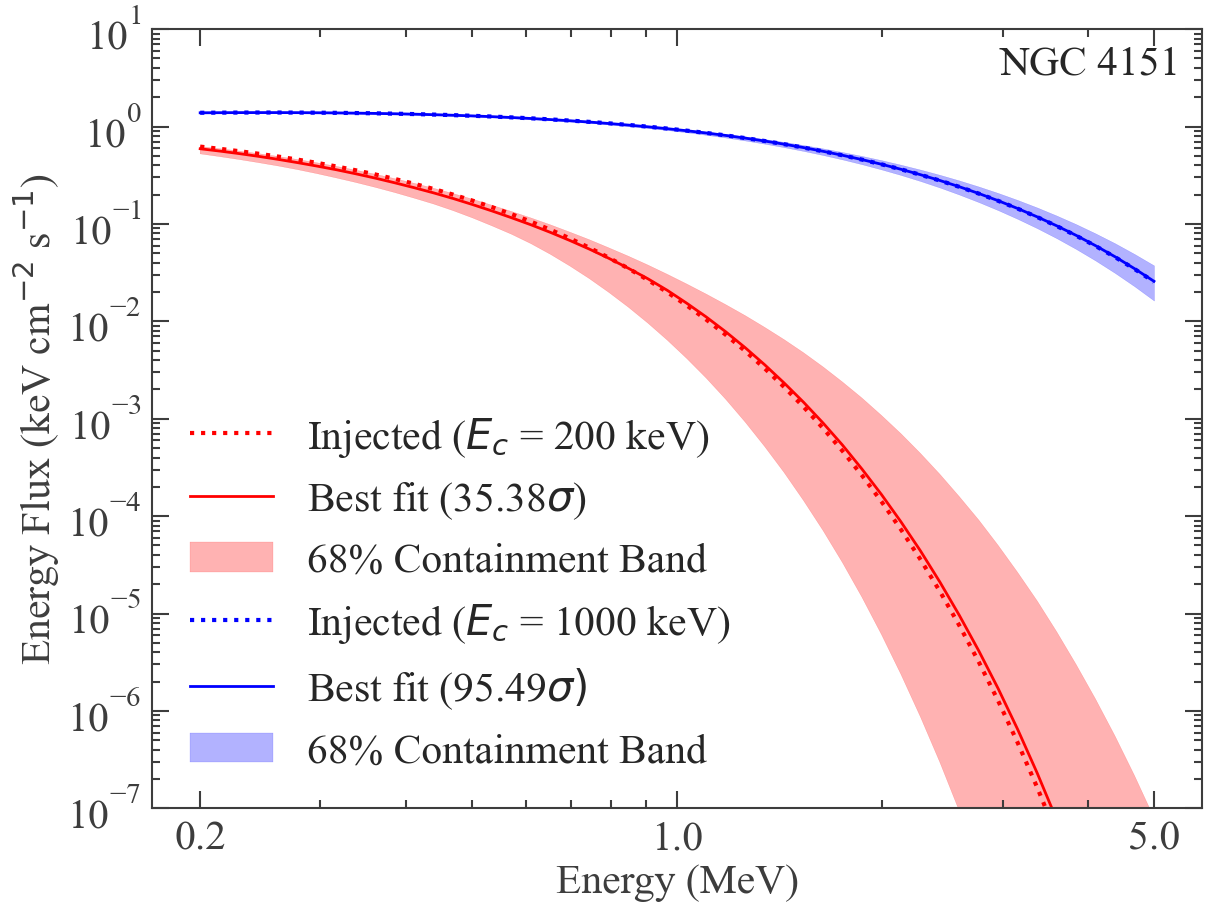

In [ ]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

Sigma = np.sqrt(TS)
Sigma_ec1000 = np.sqrt(TS_ec1000)

# # NGC 4151
text = f'NGC 4151'

ax.plot(energy, energy*energy*flux_inj, color = 'red', ls = ":", lw=3, label = "Injected ($E_c$ = 200 keV)")
ax.plot(energy, energy*energy*flux_median, color = 'red', label = f"Best fit ({Sigma:.2f}$\sigma$)")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .3, color = 'red', label = "68% Containment Band")

ax.plot(energy, energy*energy*flux_inj_ec1000, color = 'blue', ls = ":", lw=3, label = "Injected ($E_c$ = 1000 keV)")
ax.plot(energy, energy*energy*flux_median_ec1000, color = 'blue', label = f"Best fit ({Sigma_ec1000:.2f}$\sigma)$")
ax.fill_between(energy, energy*energy*flux_lo_ec1000, energy*energy*flux_hi_ec1000, alpha = .3, color='blue', label = "68% Containment Band")

ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_ThModel_TH_JointFit_200_1000_3Months.pdf"

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(1e-7, 10)

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# plt.savefig(save_path)

### Faint vs Bright Plot


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'



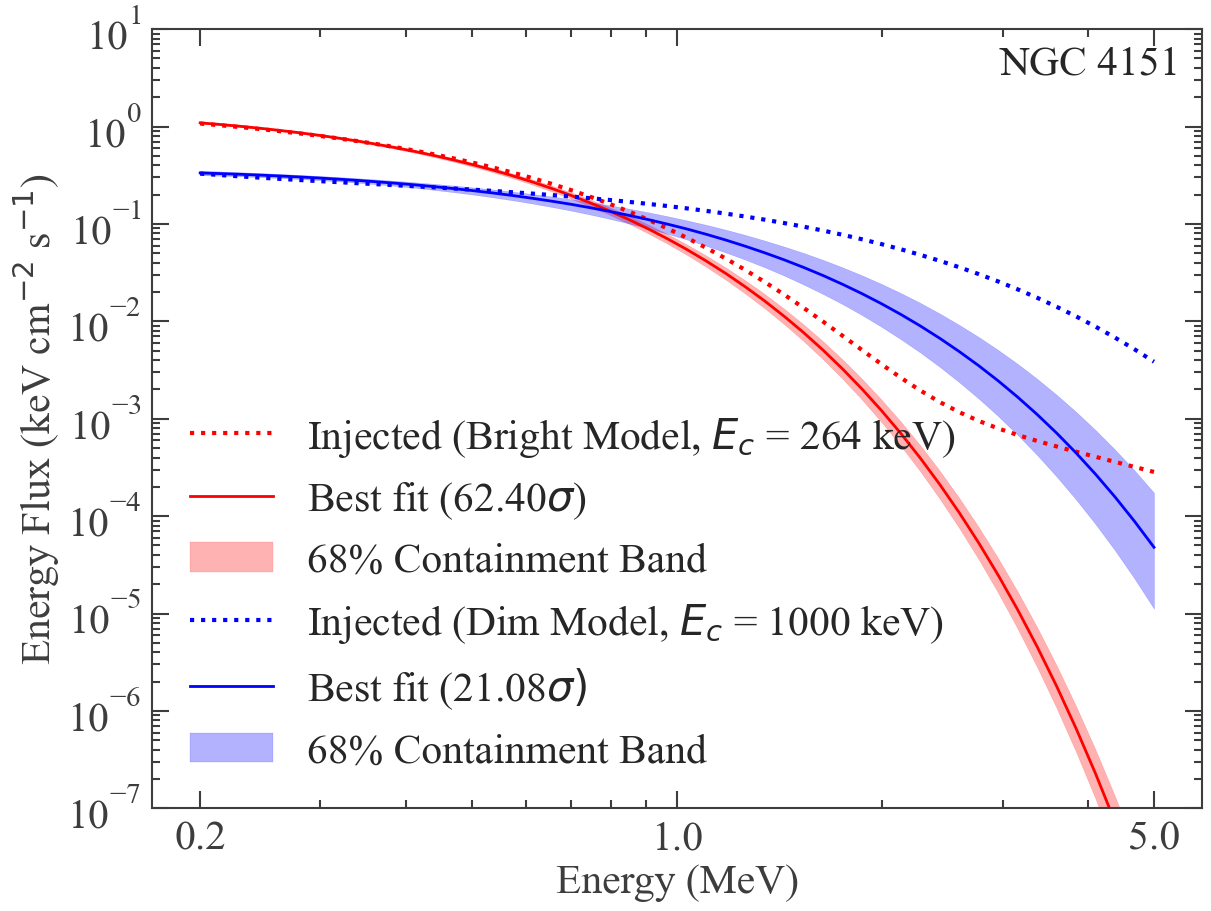

In [123]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

Sigma = np.sqrt(TS)
Sigma_ec1000 = np.sqrt(TS_ec1000)

# # NGC 4151
text = f'NGC 4151'

ax.plot(energy, energy*energy*flux_inj, color = 'red', ls = ":", lw=3, label = "Injected (Bright Model, $E_c$ = 264 keV)")
ax.plot(energy, energy*energy*flux_median, color = 'red', label = f"Best fit ({Sigma:.2f}$\sigma$)")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .3, color = 'red', label = "68% Containment Band")

ax.plot(energy, energy*energy*flux_inj_ec1000, color = 'blue', ls = ":", lw=3, label = "Injected (Dim Model, $E_c$ = 1000 keV)")
ax.plot(energy, energy*energy*flux_median_ec1000, color = 'blue', label = f"Best fit ({Sigma_ec1000:.2f}$\sigma)$")
ax.fill_between(energy, energy*energy*flux_lo_ec1000, energy*energy*flux_hi_ec1000, alpha = .3, color='blue', label = "68% Containment Band")

ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_ThModel_TH_JointFit_200_1000_3Months.pdf"

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(1e-7, 10)

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# plt.savefig(save_path)

## Thermal + Non-thermal Fit

In [ ]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
index = -3.8

spectrum = Powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.index.value = index
# spectrum.index.fix = True

# Harsher Parameters
spectrum.K.min_value = 1e-8
spectrum.K.max_value = 1e-3
spectrum.index.min_value = -5
spectrum.index.max_value = 5

# spectrum.K.delta = 5
# spectrum.index.delta = 0.25

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

source3 = PointSource("source3",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

In [60]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
index = -4

spectrum = Powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.index.value = index
# spectrum.index.fix = True

# Harsher Parameters
spectrum.K.min_value = 1e-8
spectrum.K.max_value = 1e-3
spectrum.index.min_value = -5
spectrum.index.max_value = 5

# spectrum.K.delta = 5
# spectrum.index.delta = 0.25

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

source4 = PointSource("source4",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# model = Model(source2)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)
model = Model(source1, source3)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)
model_ec1000 = Model(source2, source4)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)
cosi_ec1000.set_model(model_ec1000)

### Joint Fit

In [ ]:
# bat_ec200.use_effective_area_correction(0.02, 1.8)
# plugins = DataList(bat_ec200, cosi)

# bat_ec1000.use_effective_area_correction(0.02, 1.8)
# plugins_ec1000 = DataList(bat_ec1000, cosi_ec1000)

### Only COSI Fit

In [61]:
## Only COSI fit
plugins = DataList(cosi)
plugins_ec1000 = DataList(cosi_ec1000)

### Normal Case

In [62]:
ratio_ec200 = 0.15
link_function = Line(a=0.0, b=ratio_ec200)   # source1.K = a + b * source2.K
link_function.a.fix = True
link_function.b.fix = True             # keep ratio fixed at

ratio_ec1000 = 0.067
link_function_ec1000 = Line(a=0.0, b=ratio_ec1000)   # source1.K = a + b * source2.K
link_function_ec1000.a.fix = True
link_function_ec1000.b.fix = True             # keep ratio fixed

model.link(
    model.source3.spectrum.main.Powerlaw.K,         # dependent
    model.source1.spectrum.main.Cutoff_powerlaw.K,  # independent
    link_function,
)
model_ec1000.link(
    model_ec1000.source4.spectrum.main.Powerlaw.K,         # dependent
    model_ec1000.source2.spectrum.main.Cutoff_powerlaw.K,  # independent
    link_function_ec1000,
)

like = JointLikelihood(model, plugins, verbose = False)
like_ec1000 = JointLikelihood(model_ec1000, plugins_ec1000, verbose = False)

result = like.fit()
result_ec1000 = like_ec1000.fit()

13:50:40 INFO      set the minimizer to minuit                                             ]8;id=770851;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=974937;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=730257;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=359663;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(3.82 +/- 0.10) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.xc,(3.18 -0.12 +0.13) x 10^2,keV
background_cosi,(9.9991 +/- 0.0015) x 10^-1,


...

,-log(likelihood)
cosi,-4.199648e+08
total,-4.199648e+08


Values of statistical measures:

,statistical measures
AIC,-8.399295e+08
BIC,-8.399295e+08


Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


KeyboardInterrupt: 

### Bright and Dim Fit

In [63]:
ratio_ec200 = 0.09
link_function = Line(a=0.0, b=ratio_ec200)   # source1.K = a + b * source2.K
link_function.a.fix = True
link_function.b.fix = True             # keep ratio fixed at

ratio_ec1000 = 0.39
link_function_ec1000 = Line(a=0.0, b=ratio_ec1000)   # source1.K = a + b * source2.K
link_function_ec1000.a.fix = True
link_function_ec1000.b.fix = True             # keep ratio fixed

model.link(
    model.source3.spectrum.main.Powerlaw.K,         # dependent
    model.source1.spectrum.main.Cutoff_powerlaw.K,  # independent
    link_function,
)
model_ec1000.link(
    model_ec1000.source4.spectrum.main.Powerlaw.K,         # dependent
    model_ec1000.source2.spectrum.main.Cutoff_powerlaw.K,  # independent
    link_function_ec1000,
)

like = JointLikelihood(model, plugins, verbose = False)
like_ec1000 = JointLikelihood(model_ec1000, plugins_ec1000, verbose = False)

result = like.fit()
result_ec1000 = like_ec1000.fit()

13:50:49 INFO      set the minimizer to minuit                                             ]8;id=982363;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=504279;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=186081;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=275678;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(4.50 -0.13 +0.14) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.xc,(2.88 +/- 0.11) x 10^2,keV
background_cosi,(9.9995 +/- 0.0015) x 10^-1,


...

1.00,-0.75,0.52,-0.19
-0.75,1.00,-0.63,-0.31
0.52,-0.63,1.00,0.16
-0.19,-0.31,0.16,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-4.181657e+08
total,-4.181657e+08


Values of statistical measures:

,statistical measures
AIC,-8.363314e+08
BIC,-8.363314e+08


Profiling likelihood:   0%|          | 0/40 [00:00<?, ?it/s]

Profiling likelihood:   0%|          | 0/40 [00:00<?, ?it/s]

Profiling likelihood:   0%|          | 0/40 [00:00<?, ?it/s]

Profiling likelihood:   0%|          | 0/40 [00:00<?, ?it/s]

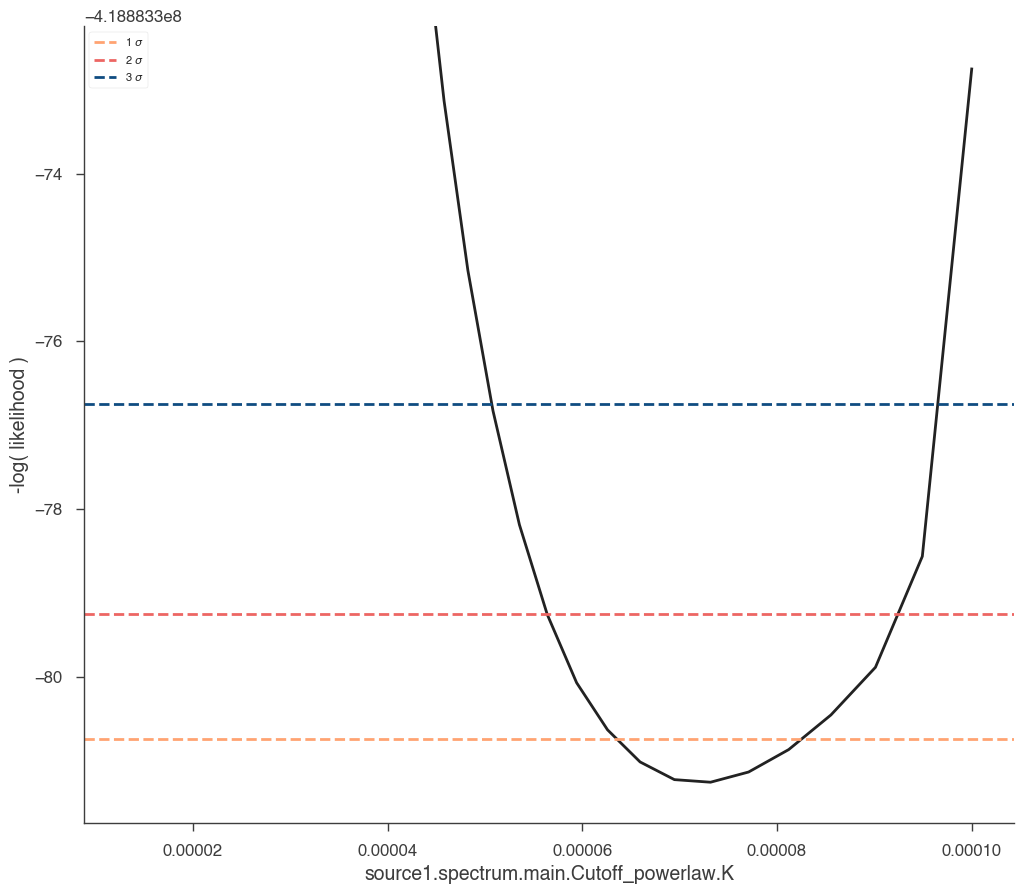

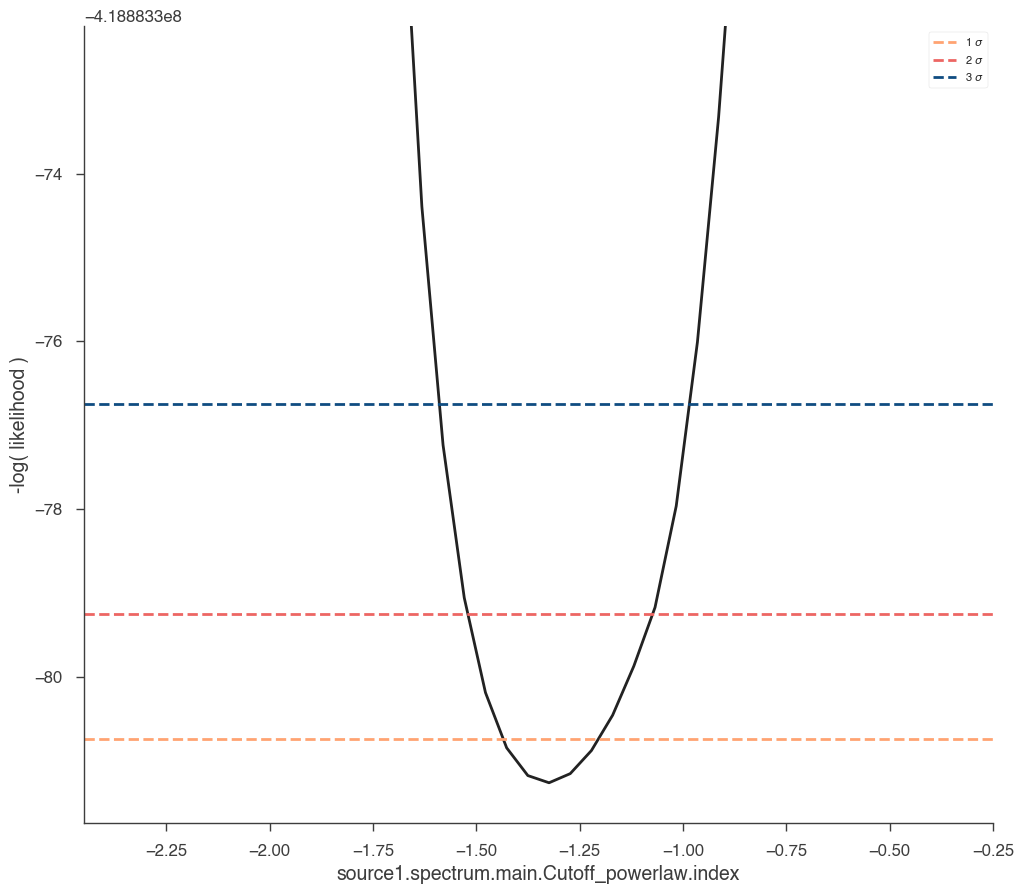

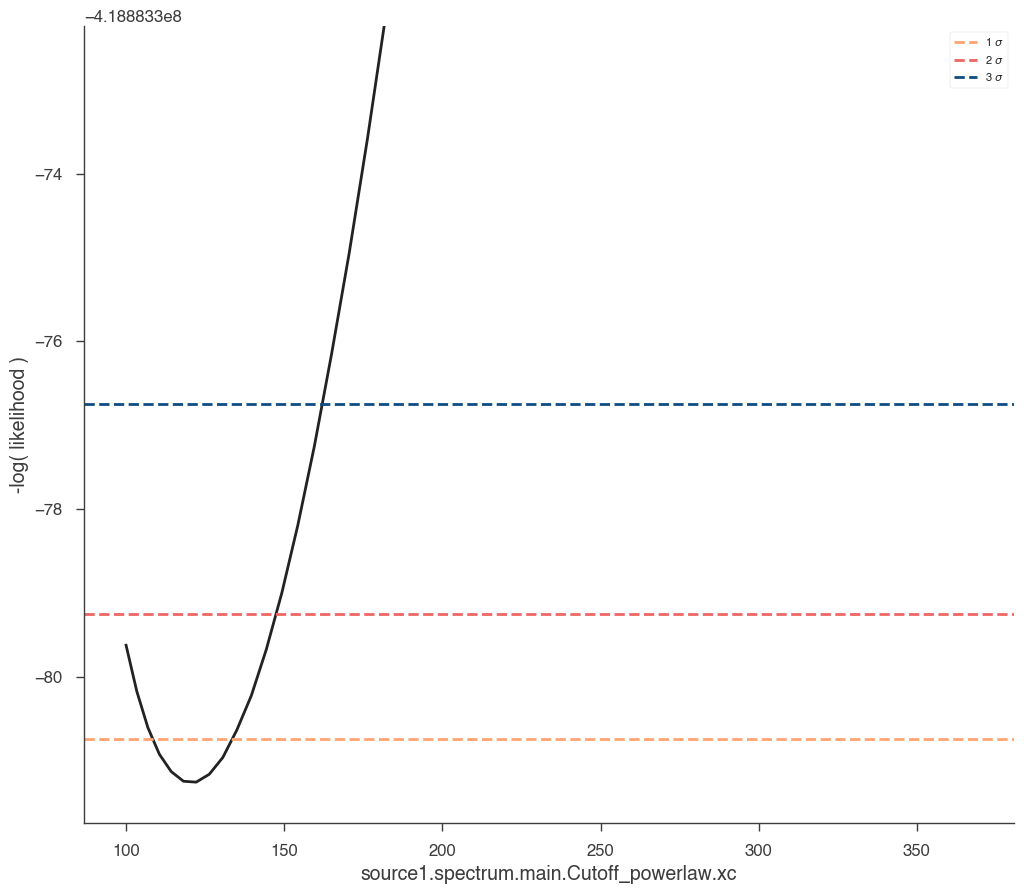

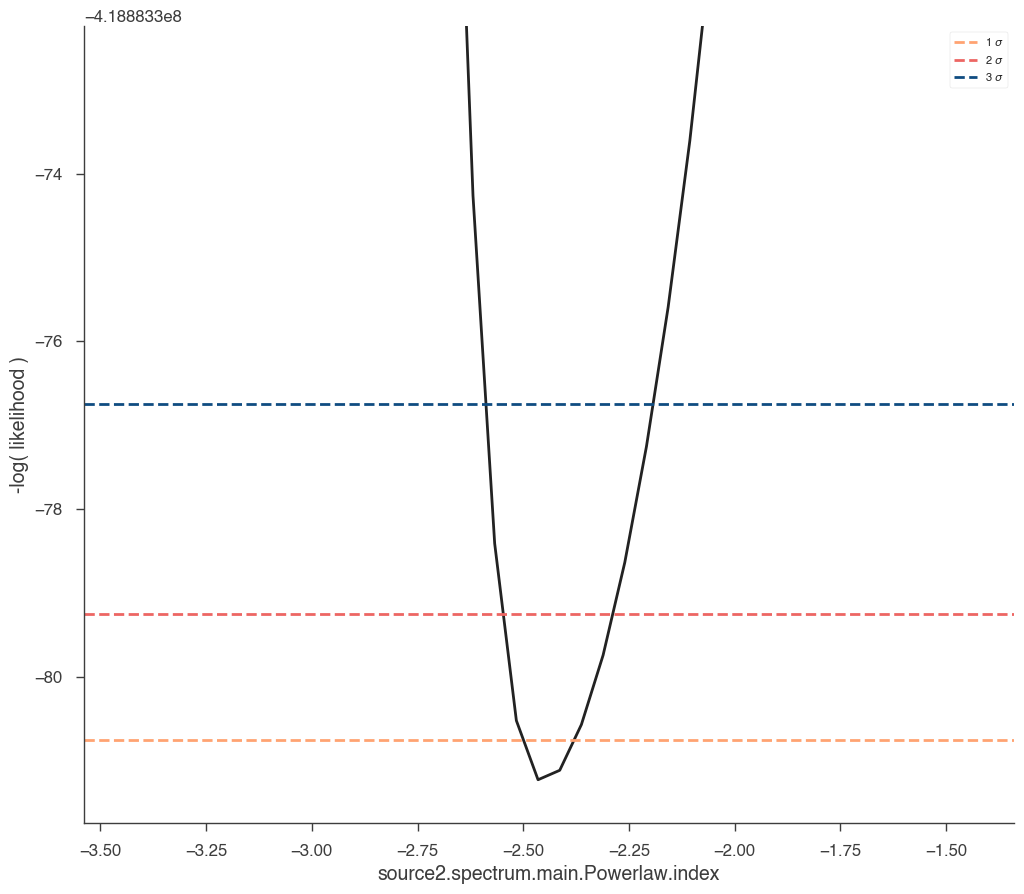

In [60]:
thermal_k_path = "source1.spectrum.main.Cutoff_powerlaw.K"
thermal_idx_path = "source1.spectrum.main.Cutoff_powerlaw.index"
thermal_xc_path = "source1.spectrum.main.Cutoff_powerlaw.xc"
tail_idx_path = "source2.spectrum.main.Powerlaw.index"

def get_profile(like, results, path, scale_low=None, scale_high=None, delta_low=None, delta_high=None, log=False, n_steps=40):
    best = like.likelihood_model[path].value
    pmin, pmax = like.likelihood_model[path].bounds

    pmin = -np.inf if pmin is None else pmin
    pmax = np.inf if pmax is None else pmax

    if scale_low is not None:
        low = max(best * scale_low, pmin)
    else:
        low = max(best + delta_low, pmin)

    if scale_high is not None:
        high = min(best * scale_high, pmax)
    else:
        high = min(best + delta_high, pmax)

    x, _, prof, fig = like.get_contours(
        path,
        param_1_minimum=low,
        param_1_maximum=high,
        param_1_n_steps=n_steps,
        progress=True,
        log=(log,),
    )

    delta_ts = 2 * (prof - prof.min())
    return x, delta_ts, fig

x_k, dts_k, _ = get_profile(like, results, thermal_k_path, scale_low=0.3, scale_high=3.0, log=True)
x_idx, dts_idx, _ = get_profile(like, results, thermal_idx_path, delta_low=-1.0, delta_high=1.0, log=False)
x_xc, dts_xc, _ = get_profile(like, results, thermal_xc_path, scale_low=0.3, scale_high=3.0, log=True)
x_tail_idx, dts_tail_idx, _ = get_profile(like, results, tail_idx_path, delta_low=-1.0, delta_high=1.0, log=False)

In [64]:
def make_null_likelihood(data_hist):
    cosi_null = COSILike("cosi",                                                # COSI 3ML plugin
                     dr = dr,                                                    # detector response
                     data = data_hist.project('Em', 'Phi', 'PsiChi'),            # data (source+background)
                     bkg = bkg.project('Em', 'Phi', 'PsiChi'),                   # background model
                     sc_orientation = sc_orientation,                            # spacecraft orientation
                     nuisance_param = bkg_par,                                   # background parameter
                     earth_occ = True)                                           # Match the source fits

    spectrum_null = Powerlaw()
    spectrum_null.K.value = 1e-30
    spectrum_null.index.value = 1
    spectrum_null.K.fix = True
    spectrum_null.index.fix = True

    source_null = PointSource(
        "source_null",
        l=l,
        b=b,
        spectral_shape=spectrum_null,
    )

    model_null = Model(source_null)
    cosi_null.set_model(model_null)

    plugins_null = DataList(cosi_null)
    like_null = JointLikelihood(model_null, plugins_null, verbose=False)
    like_null.fit()

    return like_null

like_null_200 = make_null_likelihood(NGC4151_ec200_bkg)
like_null_1000 = make_null_likelihood(NGC4151_ec1000_bkg)

TS = 2 * (
    like_null_200.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

TS_ec1000 = 2 * (
    like_null_1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

print("L1", -like.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null_200.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS)
print("Significance [200 keV]: ", np.sqrt(TS))

print("L1", -like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null_1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS_ec1000)
print("Significance [1000 keV]: ", np.sqrt(TS_ec1000))

13:52:23 INFO      set the minimizer to minuit                                             ]8;id=542913;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=10986;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
background_cosi,1.00562 +/- 0.00012,


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-4.181655e+08
total,-4.181655e+08


Values of statistical measures:

,statistical measures
AIC,-8.363309e+08
BIC,-8.363309e+08


L1 419964775.3564839
L0 419962827.6245561
TS Value:  3895.4638555049896
Significance [200 keV]:  62.41365119511107
L1 418165688.95151734
L0 418165462.0919018
TS Value:  453.7192311286926
Significance [1000 keV]:  21.300686165677682


62.4297

In [65]:
results = like.results
results_ec1000 = like_ec1000.results

print(results.display())

# Collect parameters from BOTH sources
parameters_source1 = {
    par.name: results.get_variates(par.path)
    for par in results.optimized_model["source1"].parameters.values()
    if par.free
}

parameters_source3 = {
    par.name: results.get_variates(par.path)
    for par in results.optimized_model["source3"].parameters.values()
    if par.free
}

# Collect parameters from BOTH sources
parameters_source2_ec1000 = {
    par.name: results_ec1000.get_variates(par.path)
    for par in results_ec1000.optimized_model["source2"].parameters.values()
    if par.free
}

parameters_source4_ec1000 = {
    par.name: results_ec1000.get_variates(par.path)
    for par in results_ec1000.optimized_model["source4"].parameters.values()
    if par.free
}

# Propagate errors for each source separately
results_err_source1 = results.propagate(
    results.optimized_model["source1"].spectrum.main.shape.evaluate_at,
    **parameters_source1
)

results_err_source3 = results.propagate(
    results.optimized_model["source3"].spectrum.main.shape.evaluate_at,
    **parameters_source3
)

# Propagate errors for each source separately
results_err_source2_ec1000 = results_ec1000.propagate(
    results_ec1000.optimized_model["source2"].spectrum.main.shape.evaluate_at,
    **parameters_source2_ec1000
)

results_err_source4_ec1000 = results_ec1000.propagate(
    results_ec1000.optimized_model["source4"].spectrum.main.shape.evaluate_at,
    **parameters_source4_ec1000
)

# Print both sources
# print("\n=== Source 1 (Cutoff Power Law) ===")
# print(results.optimized_model["source1"])
# print("\n=== Source 2 (Power Law) ===")
# print(results.optimized_model["source2"])

Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(4.50 -0.13 +0.14) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.xc,(2.88 +/- 0.11) x 10^2,keV
background_cosi,(9.9995 +/- 0.0015) x 10^-1,


Correlation matrix:

1.00,-0.84,-0.13
-0.84,1.00,-0.24
-0.13,-0.24,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-4.199648e+08
total,-4.199648e+08


Values of statistical measures:

,statistical measures
AIC,-8.399296e+08
BIC,-8.399296e+08


None


In [66]:
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

flux_lo_ec1000 = np.zeros_like(energy)
flux_median_ec1000 = np.zeros_like(energy)
flux_hi_ec1000 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)

# Add arrays for individual components
flux_median_source1 = np.zeros_like(energy)
flux_median_source3 = np.zeros_like(energy)

flux_median_source2_ec1000 = np.zeros_like(energy)
flux_median_source4_ec1000 = np.zeros_like(energy)

for i, e in enumerate(energy):
    # Evaluate each source separately
    flux1 = results_err_source1(e)
    flux2 = results_err_source3(e)

    flux1_ec1000 = results_err_source2_ec1000(e)
    flux2_ec1000 = results_err_source4_ec1000(e)

    # Store individual components
    flux_median_source1[i] = flux1.median
    flux_median_source3[i] = flux2.median
    flux_median_source2_ec1000[i] = flux1_ec1000.median
    flux_median_source4_ec1000[i] = flux2_ec1000.median

    # Add the RandomVariates directly
    flux_combined = flux1 + flux2
    flux_combined_ec1000 = flux1_ec1000 + flux2_ec1000
    
    # Get median and intervals from the combined distribution
    flux_median[i] = flux_combined.median
    flux_lo[i], flux_hi[i] = flux_combined.equal_tail_interval(cl=0.68)

    flux_median_ec1000[i] = flux_combined_ec1000.median
    flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_combined_ec1000.equal_tail_interval(cl=0.68)
    
    flux_inj[i] = spectrum_inj_ec200_total.evaluate_at(e)
    flux_inj_ec1000[i] = spectrum_inj_ec1000_total.evaluate_at(e)

binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
binned_energy = np.array([])
bin_sizes = np.array([])
binned_energy_ec1000 = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])
    
    binned_energy_ec1000 = np.append(binned_energy_ec1000, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)


expectation = cosi._expected_counts['source1'] + cosi._expected_counts['source3']
expectation = cosi_ec1000._expected_counts['source2'] + cosi_ec1000._expected_counts['source4']


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'



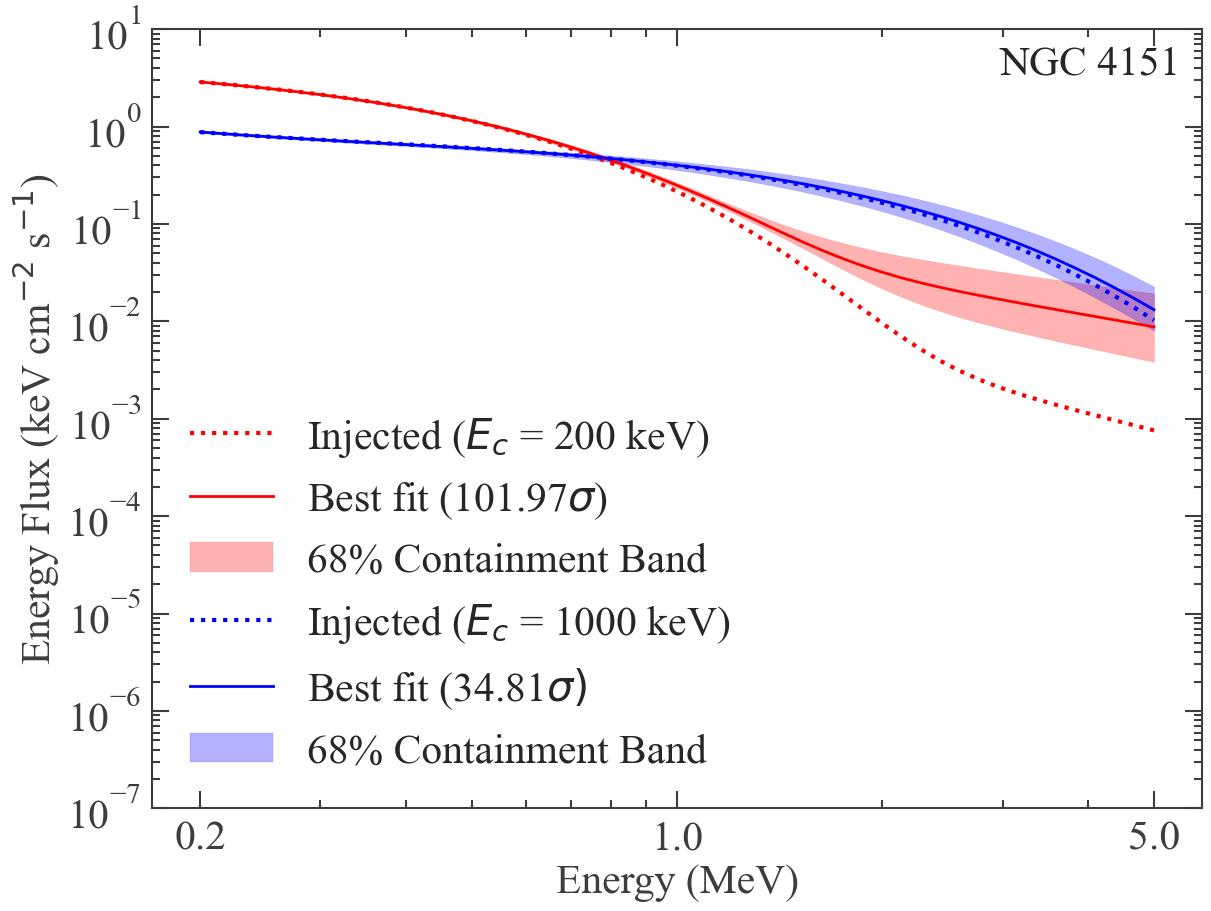

In [26]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

Sigma = np.sqrt(TS)
Sigma_ec1000 = np.sqrt(TS_ec1000)

# # NGC 4151
text = f'NGC 4151'

# Plot individual components
# ax.plot(energy, energy*energy*flux_median_source1, label = "Cutoff PL", color = 'red', ls='--', alpha=0.7)
# ax.plot(energy, energy*energy*flux_median_source3, label = "Power Law", color = 'red', ls='-.', alpha=0.7)
# Total component
ax.plot(energy, energy*energy*flux_inj, color = 'red', ls = ":", lw=3, label = "Injected ($E_c$ = 200 keV)")
ax.plot(energy, energy*energy*flux_median, color = 'red', label = f"Best fit ({Sigma:.2f}$\sigma$)")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .3, color = 'red', label = "68% Containment Band")

# Plot individual components
# ax.plot(energy, energy*energy*flux_median_source2_ec1000, label = "Cutoff PL", color = 'blue', ls='--', alpha=0.7)
# ax.plot(energy, energy*energy*flux_median_source4_ec1000, label = "Power Law", color = 'blue', ls='-.', alpha=0.7)
# Total component
ax.plot(energy, energy*energy*flux_inj_ec1000, color = 'blue', ls = ":", lw=3, label = "Injected ($E_c$ = 1000 keV)")
ax.plot(energy, energy*energy*flux_median_ec1000, color = 'blue', label = f"Best fit ({Sigma_ec1000:.2f}$\sigma)$")
ax.fill_between(energy, energy*energy*flux_lo_ec1000, energy*energy*flux_hi_ec1000, alpha = .3, color='blue', label = "68% Containment Band")

ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_ThNthModel_TH_NTH_Fit_200_1000_9Months_FrozenIndex.pdf"

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(1e-7, 10)

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# plt.savefig(save_path)


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'



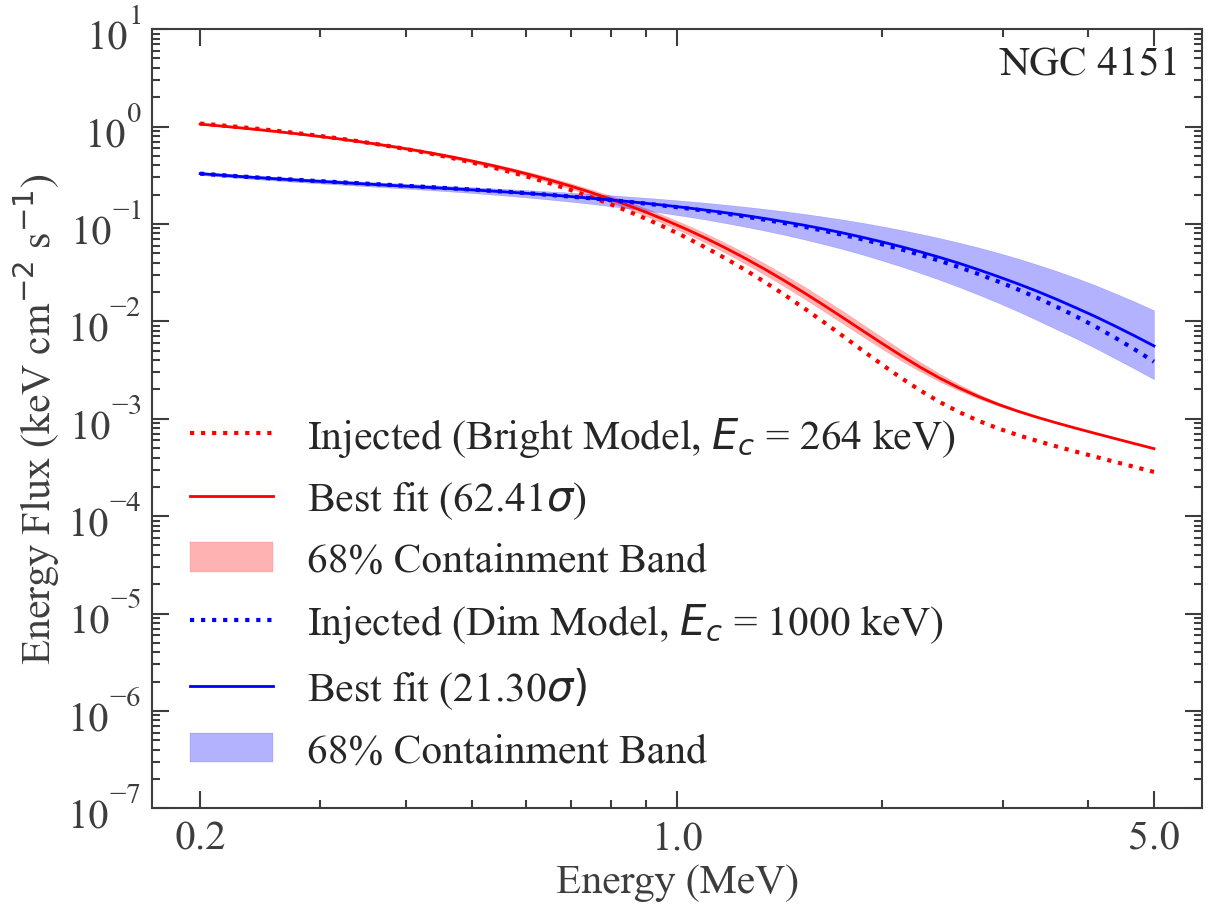

In [67]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

Sigma = np.sqrt(TS)
Sigma_ec1000 = np.sqrt(TS_ec1000)

# # NGC 4151
text = f'NGC 4151'

ax.plot(energy, energy*energy*flux_inj, color = 'red', ls = ":", lw=3, label = "Injected (Bright Model, $E_c$ = 264 keV)")
ax.plot(energy, energy*energy*flux_median, color = 'red', label = f"Best fit ({Sigma:.2f}$\sigma$)")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .3, color = 'red', label = "68% Containment Band")

ax.plot(energy, energy*energy*flux_inj_ec1000, color = 'blue', ls = ":", lw=3, label = "Injected (Dim Model, $E_c$ = 1000 keV)")
ax.plot(energy, energy*energy*flux_median_ec1000, color = 'blue', label = f"Best fit ({Sigma_ec1000:.2f}$\sigma)$")
ax.fill_between(energy, energy*energy*flux_lo_ec1000, energy*energy*flux_hi_ec1000, alpha = .3, color='blue', label = "68% Containment Band")

ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_ThModel_TH_JointFit_200_1000_3Months.pdf"

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(1e-7, 10)

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# plt.savefig(save_path)